<a href="https://colab.research.google.com/github/ericiortega/aipi590-xai-fall2025/blob/main/assignments/explainable_techniques_ii/02_explainability_california_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Techniques II: California Housing (PDP, ICE, ALE)

**Course:** AIPI 590 – Emerging Trends in Explainable AI (Fall 2025)  
**Professor:** Dr. Brinnae Bent  
**Author:** Eric Ortega Rodriguez  
**Case Domain:** Housing Price Prediction  
**Assigned Task:** Explainable Techniques II (PDP, ICE, ALE)  
**Dataset:** [California Housing Dataset (Cleaned)](https://raw.githubusercontent.com/ericiortega/aipi590-xai-fall2025/main/data/processed/california_housing_clean.csv)  
**Deadline:** Mon Sep 29, 2025 – 11:30 AM  
**GitHub Repo:** [Assignment Folder](https://github.com/ericiortega/aipi590-xai-fall2025/tree/main/assignments/explainable_techniques_ii)  


In [20]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (10, 4.5), "figure.dpi": 130})# this line of code was recommended by Chatgpt so the graphs can appear better in the notebook.

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay



california_data = "https://raw.githubusercontent.com/ericiortega/aipi590-xai-fall2025/main/data/processed/california_housing_clean.csv"
df = pd.read_csv(california_data)

print(df.shape)
df.head()


(20640, 13)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,452600.0,False,False,True,False
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,358500.0,False,False,True,False
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,352100.0,False,False,True,False
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,341300.0,False,False,True,False
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,342200.0,False,False,True,False


## Train/test split + baseline model

In [7]:
target = "median_house_value"
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
r2  = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)

print(f"RF(300) — R²={r2:.3f}, MAE=${mae:,.0f} | train={len(X_train)}, test={len(X_test)} | target={target}")


RF(300) — R²=0.818, MAE=$31,473 | train=16512, test=4128 | target=median_house_value


## Data / Model
- **Dataset:** California Housing (cleaned)
- **Target:** `median_house_value`
- **Model:** RandomForestRegressor (300 trees), 80/20 train–test split

## Performance
- **R² = 0.818** — model explains ~82% of variance on the test set.
- **MAE ≈ $31,473** — typical absolute prediction error in dollars.

## What the plots are & why (from Week 5 notes)
- **PDP — Partial Dependence Plot**  
  *What:* Shows how the prediction changes as one feature varies **averaging over other features** (global effect).  
  *Why:* Simple global summary for direction/shape.  
  *Caution:* Can be **misleading when features are correlated** (averages over unrealistic combos).

- **ICE — Individual Conditional Expectation**  
  *What:* One curve **per instance**; shows how that instance’s prediction changes as a feature varies with others fixed.  
  *Why:* Reveals **heterogeneity** and potential **interactions** (non-parallel curves).  
  *Caution:* Still conditions on potentially unrealistic combos when features are correlated.

- **ALE — Accumulated Local Effects**  
  *What:* Computes **local effects** within bins where data exist and **accumulates** them along the feature range (distribution-aware).  
  *Why:* More **robust under correlated features** than PDP.  
  *Caution:* **Bin choice** affects smoothness; still a global summary.

## My Next Steps
1. Select 6 features to explain (guided by feature importance/domain context).
2. Generate **PDP** (global average effects) with concise captions.
3. Generate **ICE** (individual curves) to reveal heterogeneity/interaction.
4. Generate **ALE** to check/confirm effects under feature correlation.
5. Run a **correlation check** to support PDP vs. ALE discussion.
6. Summarize key findings and takeaways.


In [25]:
# Choose the features you'll explain (compact, interpretable, numeric for ALE)
numeric_cols = X.select_dtypes(include=["float64","int64"]).columns
features_to_explain = [
    f for f in [
        "median_income",
        "housing_median_age",
        "total_rooms",
        "population",
        "latitude",
        "longitude",
    ] if f in numeric_cols
]

## Identifying Features

In [8]:
numeric_cols = X.select_dtypes(include=["float64","int64"]).columns

# choose ~5–6 features (edit as you like)
features_to_explain = [f for f in ["median_income",
                                   "housing_median_age",
                                   "total_rooms",
                                   "population",
                                   "latitude",
                                   "longitude"] if f in numeric_cols]
features_to_explain


,0
median_income,0.490046
ocean_proximity_INLAND,0.141386
longitude,0.106199
latitude,0.101517
housing_median_age,0.052559
population,0.032527
total_rooms,0.023726
total_bedrooms,0.023663
households,0.018155
ocean_proximity_NEAR OCEAN,0.008965


['median_income',
 'housing_median_age',
 'total_rooms',
 'population',
 'latitude',
 'longitude']

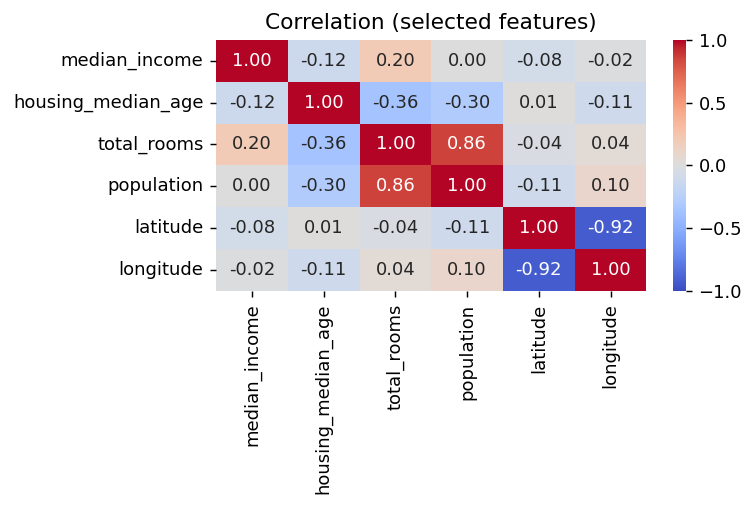

In [27]:
import seaborn as sns
sel = ["median_income","housing_median_age","total_rooms","population","latitude","longitude"]
corr = df[sel].corr(method="pearson")
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="coolwarm", fmt=".2f")
plt.title("Correlation (selected features)")
plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


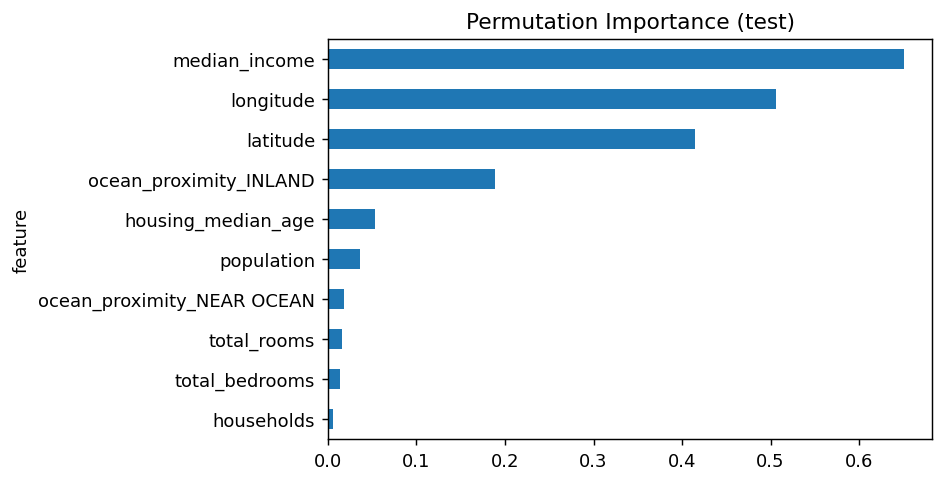

In [29]:
from sklearn.inspection import permutation_importance

r = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
imp_df = (pd.DataFrame({"feature": X.columns,
                        "importance": r.importances_mean,
                        "std": r.importances_std})
          .sort_values("importance", ascending=False))
imp_df.head(10)
(imp_df.set_index("feature")["importance"].head(10)
      .plot(kind="barh", figsize=(6,4)))
plt.title("Permutation Importance (test)")
plt.gca().invert_yaxis()
plt.show()


## Correlation Check & Why It Matters
- **Observed correlations:**  
  - `total_rooms` ↔ `households` / `population` (size–density bundle).  
  - `latitude` ↔ `longitude` and with coastal proximity indicators.

- **Implications for explanations:**  
  - **PDP** can **attribute shared signal** to the feature being varied (inflated effects) when features are correlated.  
  - **ALE** integrates **local** changes along the **empirical distribution**, avoiding unrealistic combinations and giving a more reliable marginal effect.

- **How to use this:**  
  - Treat PDP as a **broad trend**.  
  - Use ICE to **spot heterogeneity/interactions**.  
  - Rely on ALE to **confirm** effects under **correlation**.


## Partial Dependence Plot (PDP)

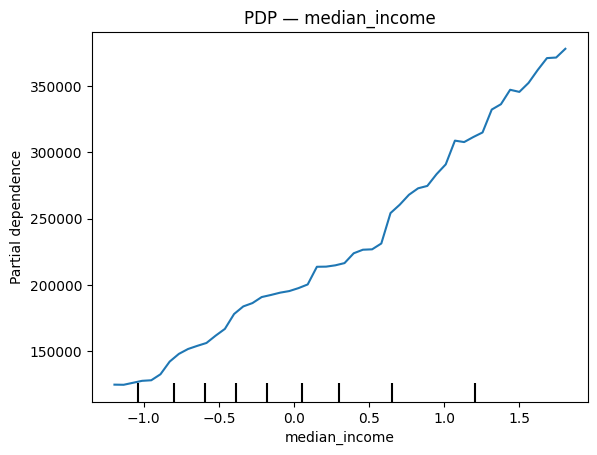

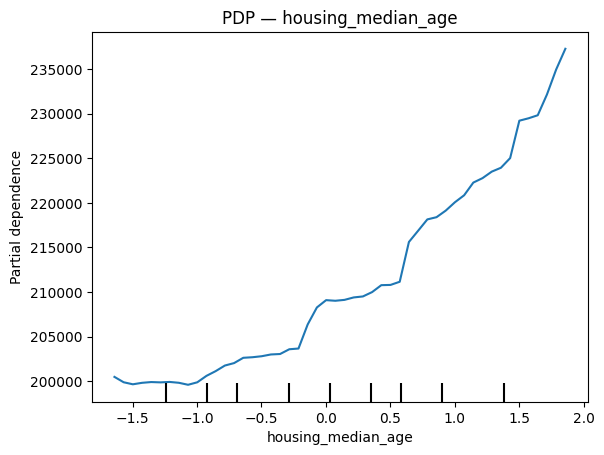

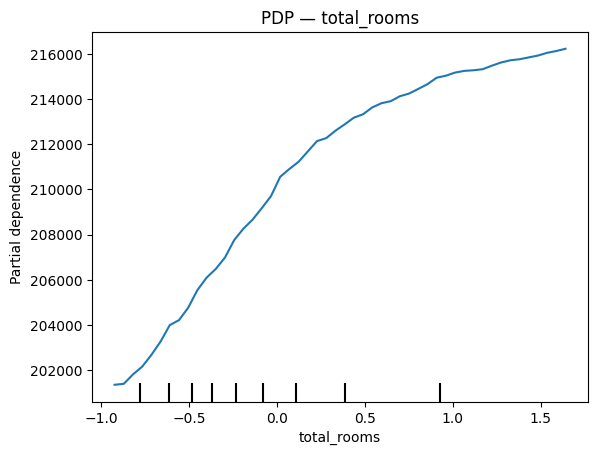

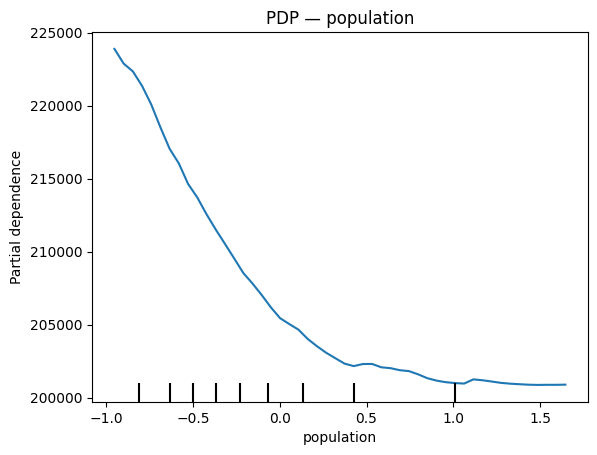

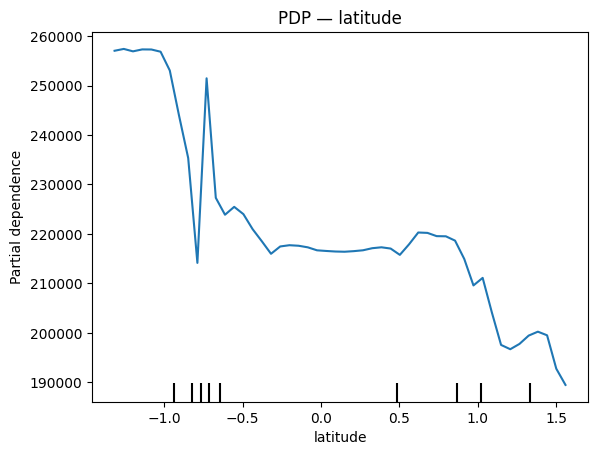

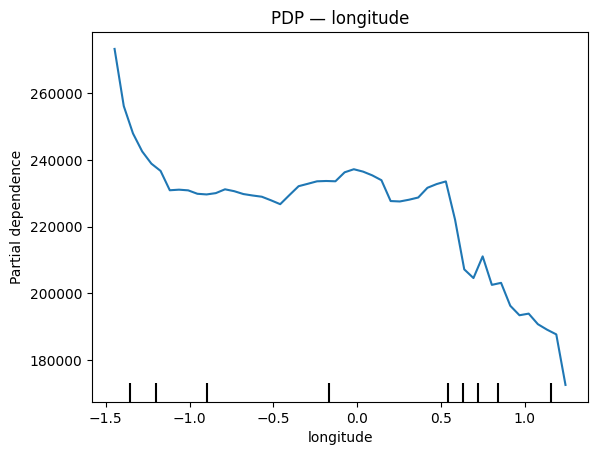

In [9]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

for f in features_to_explain:
    PartialDependenceDisplay.from_estimator(rf, X, [f], kind="average", grid_resolution=50)
    plt.title(f"PDP — {f}")
    plt.show()


## PDP — Global Average Effects (Interpretation)
PDP shows the **average** change in prediction as one feature varies, holding others fixed.

- **`median_income`**: Strong, **monotonic ↑**; steep up to ~+1.5σ then gentler (diminishing returns).  
  *Takeaway:* Higher-income tracts predict much higher prices; dominant driver.

- **`total_rooms`**: Mild **positive** slope.  
  *Takeaway:* More rooms → higher predicted price, but effect size is modest; may be inflated by correlation with density variables.

- **`population`**: Overall **decreasing** trend.  
  *Takeaway:* Denser tracts tend to have lower predicted prices in this dataset.

- **`latitude`**: **Downward** with increasing latitude (north).  
  *Takeaway:* Southern CA and Bay Area pockets have higher prices than much of the north.

- **`longitude`**: Prices **fall** moving east/inland (higher longitude).  
  *Takeaway:* Clear coastal premium.

- **`housing_median_age`**: **Weak/slightly nonlinear**, near-flat overall.  
  *Takeaway:* Age contributes little once other features are included.

**Caution:** PDP can mislead when features are **correlated** (averages may reflect unrealistic combinations).


## Individual Conditional Expectation (ICE)

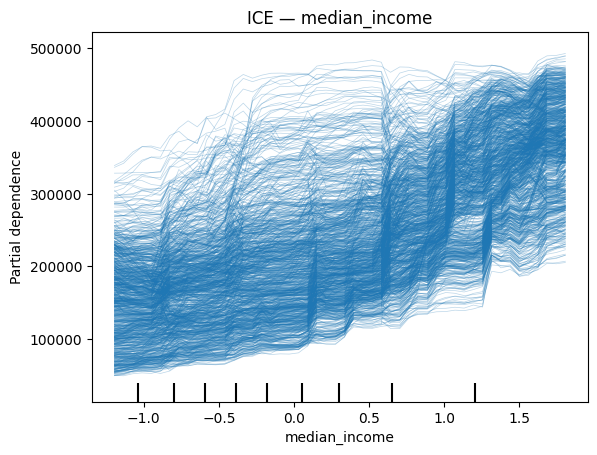

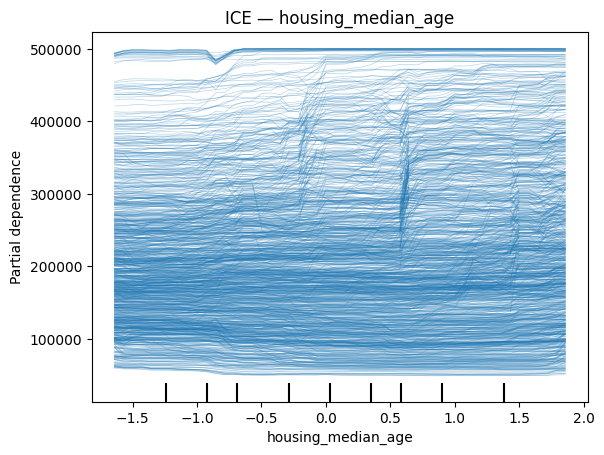

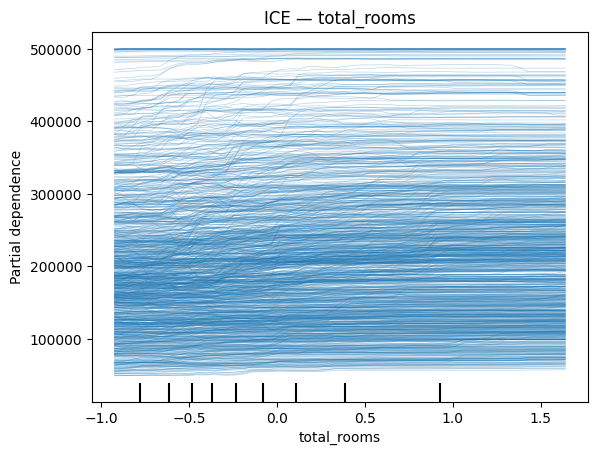

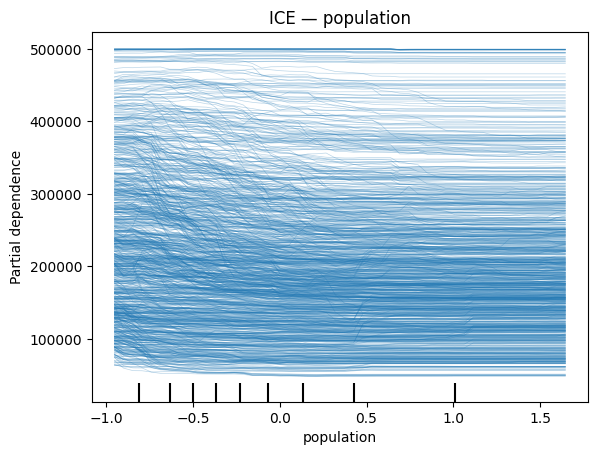

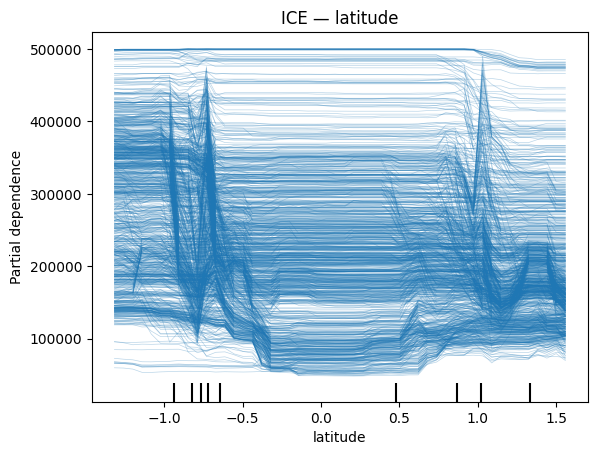

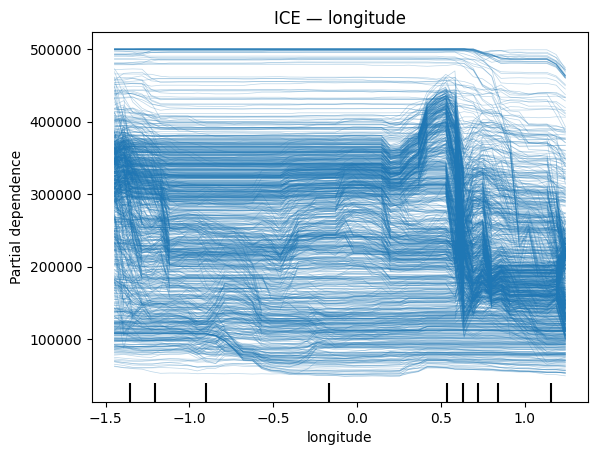

In [10]:
for f in features_to_explain:
    PartialDependenceDisplay.from_estimator(
        rf, X, [f], kind="individual", subsample=1000, random_state=42, grid_resolution=50
    )
    plt.title(f"ICE — {f}")
    plt.show()


## ICE — Individual Conditional Expectation (Interpretation)
ICE shows **one curve per instance**, revealing heterogeneity hidden by PDP averages.

- **`median_income`**: Curves are **parallel and upward**.  
  *Interpretation:* Effect is stable across tracts; limited interaction.

- **`latitude`, `longitude`**: Curves **fan out / cross**.  
  *Interpretation:* Geography interacts with other factors (e.g., coastal proximity); effects vary by region.

- **`total_rooms`, `population`, `housing_median_age`**: Smaller spread; many near-flat lines.  
  *Interpretation:* Modest or context-dependent effects; consistent with correlation and the model relying more on income/geography.


## Accumulated Local Effects (ALE)

In [13]:
!pip install git+https://github.com/MaximeJumelle/ALEPython.git#egg=alepython

  Cloning https://github.com/MaximeJumelle/ALEPython.git to /tmp/pip-install-tic7cwbq/alepython_2d8eb73b400a4296b19dea748bd42c96
  Running command git clone --filter=blob:none --quiet https://github.com/MaximeJumelle/ALEPython.git /tmp/pip-install-tic7cwbq/alepython_2d8eb73b400a4296b19dea748bd42c96
  Resolved https://github.com/MaximeJumelle/ALEPython.git to commit 286350ab674980a32270db2a0b5ccca1380312a7
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'alepython' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'alepython'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for alepython: filename=alepython-0.1.dev17+g286350ab6-py3-none-any.whl 

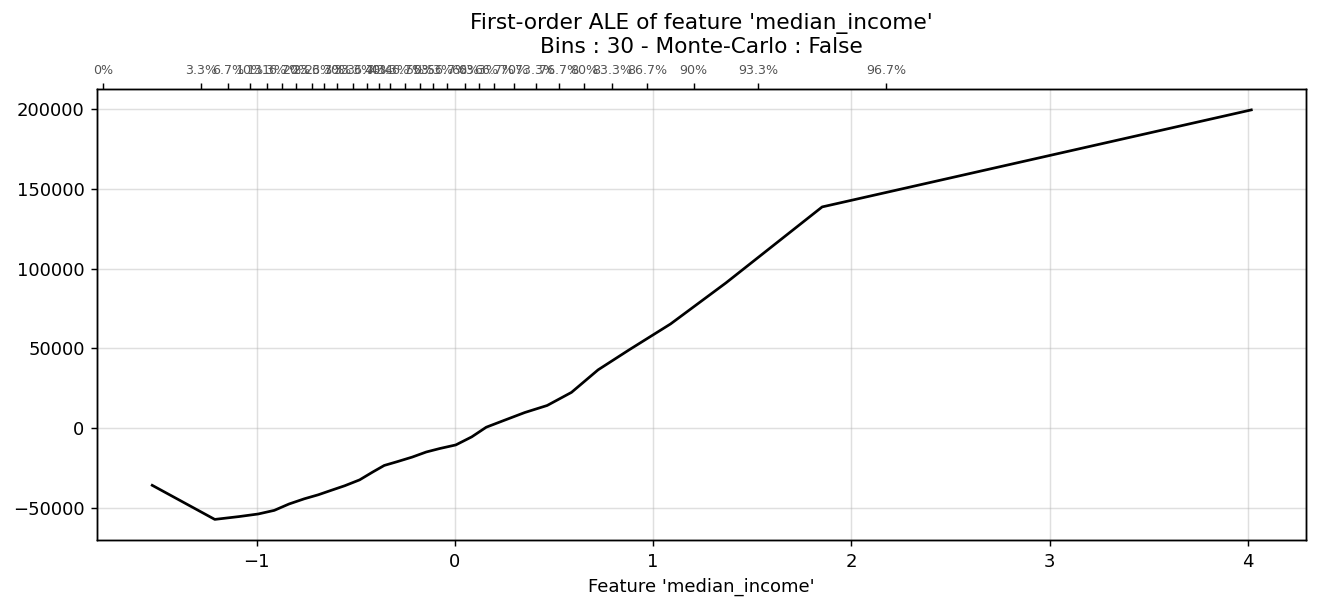

<Figure size 1560x585 with 0 Axes>

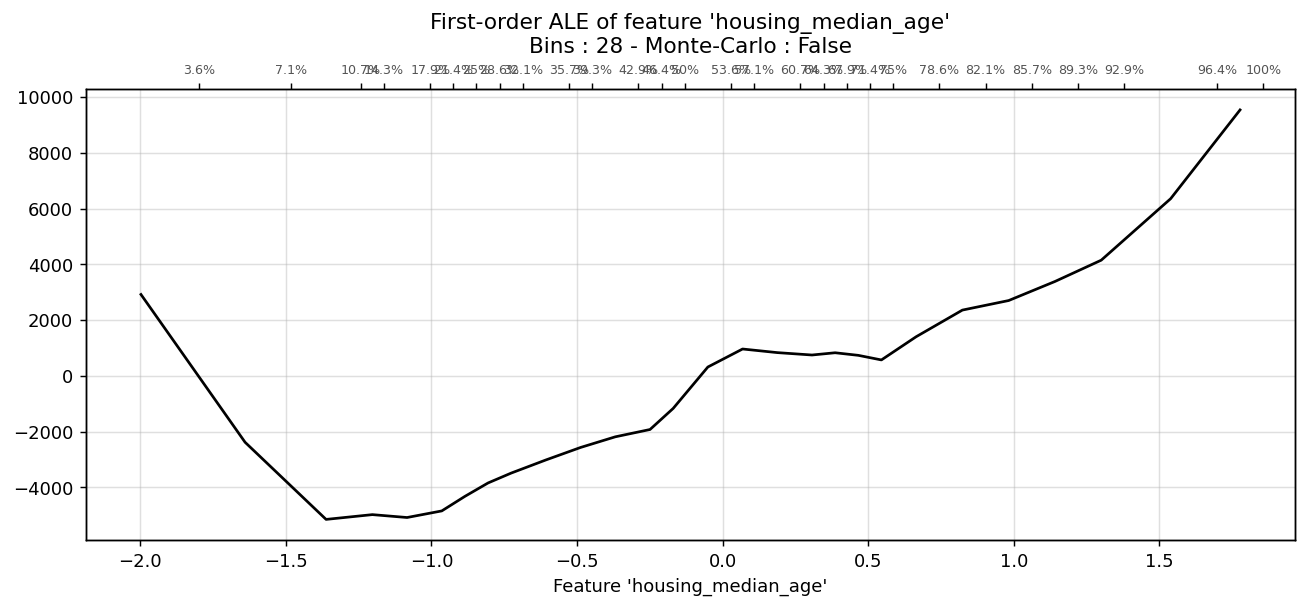

<Figure size 1560x585 with 0 Axes>

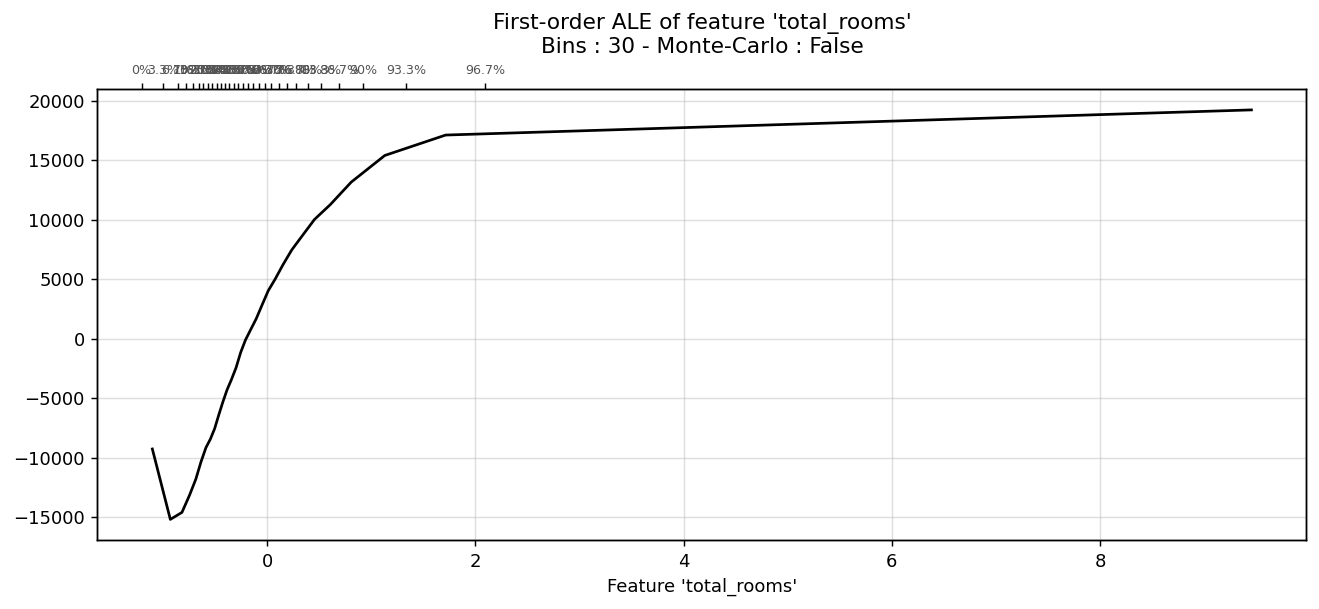

<Figure size 1560x585 with 0 Axes>

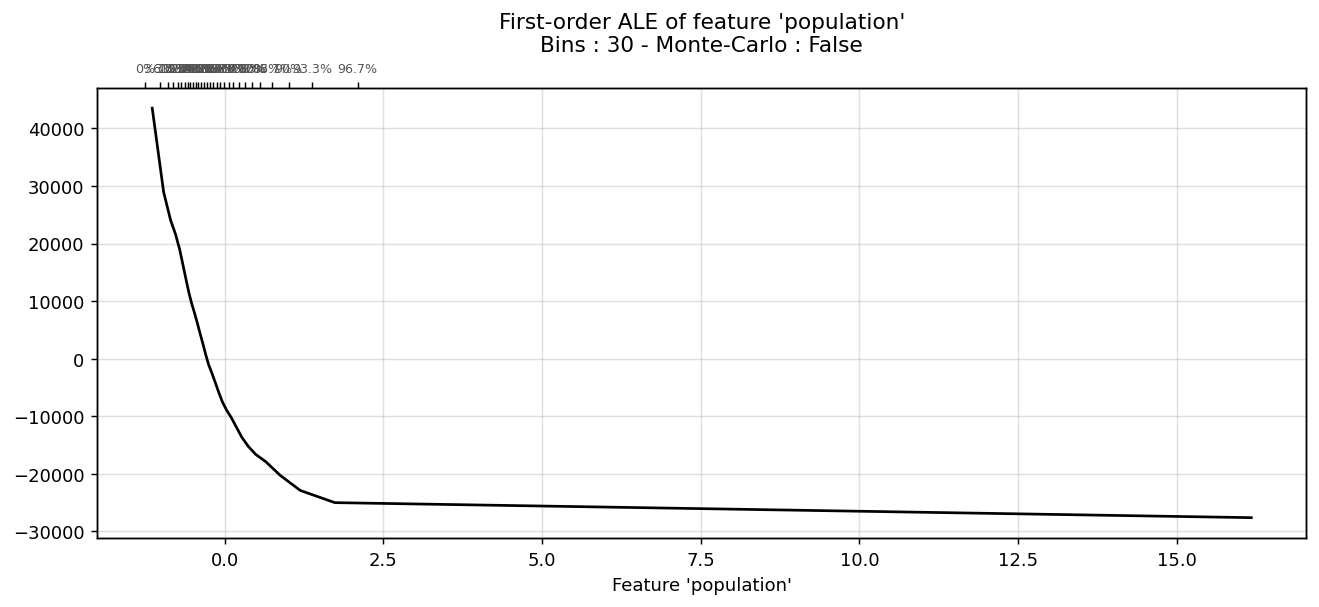

<Figure size 1560x585 with 0 Axes>

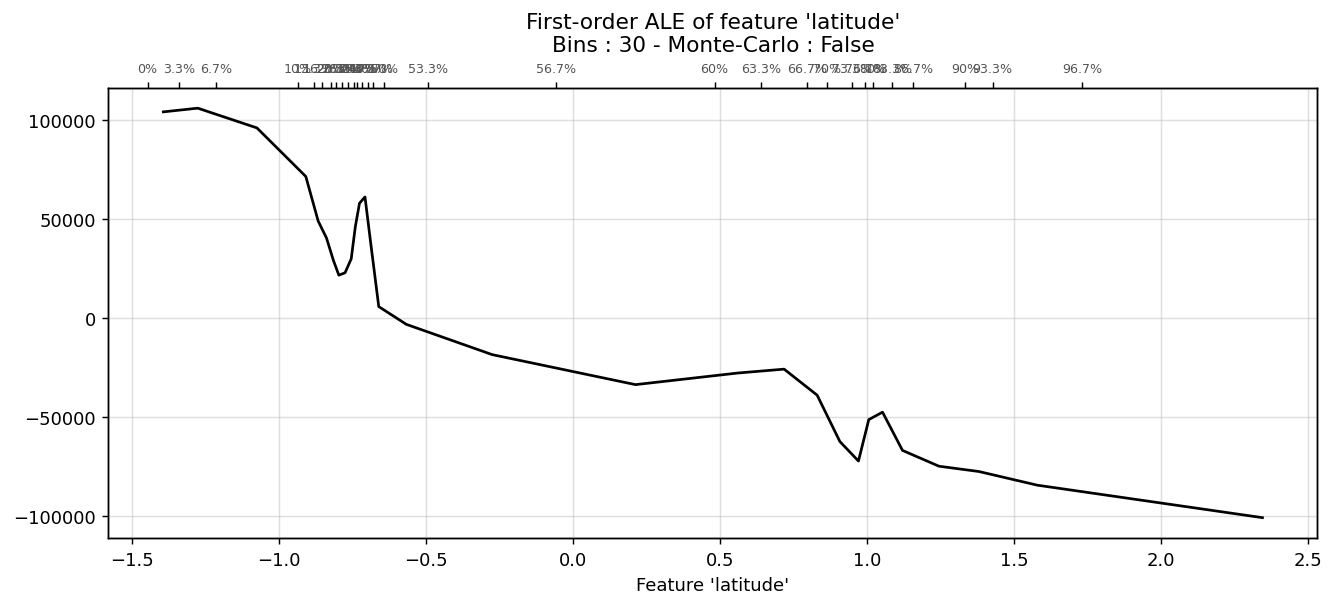

<Figure size 1560x585 with 0 Axes>

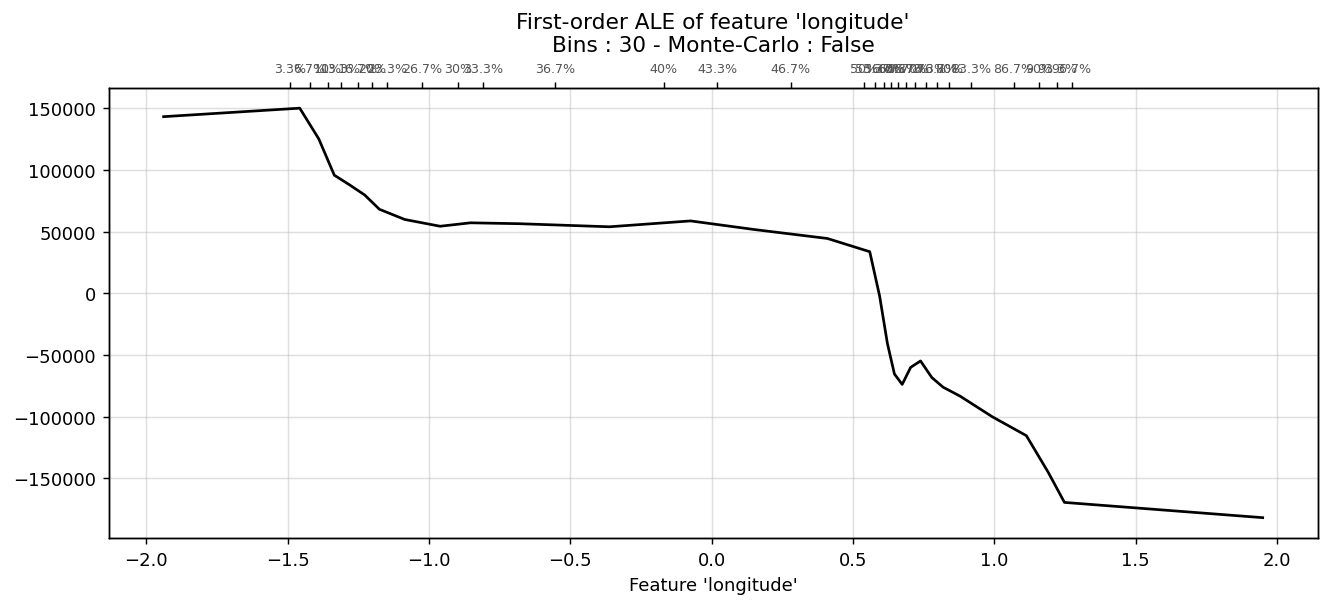

<Figure size 1560x585 with 0 Axes>

In [26]:
# ALE (optional: filter to numeric/continuous just in case)
numeric_cols = X.select_dtypes(include=["float64","int64"]).columns
features_for_ale = [f for f in features_to_explain if f in numeric_cols and X[f].nunique() > 20]

for f in features_for_ale:              # could also be features_to_explain if all are fine
    ale_plot(rf, X, f, bins=30)
    plt.tight_layout(); plt.show()

## ALE — Accumulated Local Effects (Interpretation & PDP vs. ALE)
ALE aggregates **local** changes where data exist (distribution-aware), reducing correlation bias.

- **`median_income`**: Strong **positive** effect; aligns with PDP.  
  *Takeaway:* Robust global driver.

- **`total_rooms`**: **Flatter** than PDP.  
  *Takeaway:* PDP likely overstated effect due to correlation with `households`/`population`.

- **`population`**: **Flatter** than PDP.  
  *Takeaway:* Limited independent effect once correlation is controlled.

- **`latitude`, `longitude`**: Clear **nonlinear** gradients remain.  
  *Takeaway:* Geography matters beyond correlation; coastal/west & south patterns persist.

- **`housing_median_age`**: Small, weakly nonlinear; overall minor.

**PDP vs. ALE:** Where features are correlated (size/density), **ALE moderates** PDP’s effect; for key drivers (income, geography), **PDP≈ALE**.


## Conclusions

### Key Findings
- **Income dominates:** `median_income` shows a large, monotonic positive effect across PDP, ICE, and ALE.  
- **Geography matters:** `latitude` and `longitude` exhibit strong, nonlinear spatial patterns (coastal premium, inland discount); ICE shows clear regional heterogeneity.  
- **Size/density weaken under correlation control:** Effects of `total_rooms` and `population` shrink in ALE, consistent with their collinearity.  
- **Model quality:** Test **R² ≈ 0.82** and **MAE ≈ $31k** indicate strong predictive performance.

### Limitations & Notes
- **Axes/units:** Feature values are **standardized (z-scores)**; ALE curves are **centered** (relative effect).  
- **PDP assumption:** Holding other features fixed can be unrealistic when predictors are correlated.  
- **Model-specific:** Explanations describe this **RandomForest**; other models may show different shapes/interactions.

### Stakeholder Takeaways
- Prioritize **income & location**—the most reliable drivers of predicted price.  
- **Room counts/density** are not strong independent levers once correlation is accounted for.  
- Effects vary by **region**; prefer region-aware strategies over one-size-fits-all approaches.
